# Alvin PLC Sales DB EDA Project

## Overview:

This is a sales EDA project with data obtained from the sample SQL database ("https://www.sqlskills.com/resources/conferences/salesdb2014.zip") with the aim of providing strategic data insights to further augment sales policy formulation.

Author : www.linkedin.com/in/alvin-kinoti-9129021a0

## Table of Contents

1. Importing the Libraries
2. Importing the Dataset
3. Exploring the Dataset
4. Data Wrangling
5. EDA

In [31]:
## importing the libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pyodbc

In [3]:
## importing the dataset

# 1. defining the connection string

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-0D58FFU\SQLEXPRESS;"
    "DATABASE=Sales DB Sample Database;"
    "Trusted_Connection=yes;"
)

# 2. creating a cursor
cursor = conn.cursor()

# 3. reading the data from the table
query = """
-- Alvin DB PLC combined query

SELECT 
c.CustomerID,
CONCAT(C.FirstName, ' ', c.LastName) AS Customer_Name,
CONCAT(e.FirstName, ' ', e.LastName) AS Employee_Name,
p.ProductID,
p.Name AS Product,
p.Price,
e.EmployeeID,
s.Quantity,
s.Quantity * p.Price AS Total_Sale
FROM dbo.Customers c
JOIN dbo.Sales s
ON c.CustomerID = s.CustomerID
JOIN dbo.Products p
ON p.ProductID = s.ProductID
JOIN dbo.Employees e
ON e.EmployeeID = s.SalesPersonID
ORDER BY Total_Sale DESC;
"""

df = pd.read_sql(query, conn)
df

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Alvin\AppData\Local\Temp\ipykernel_20984\3158871334.py:7: SyntaxWarning: invalid escape sequence '\S'
  "SERVER=DESKTOP-0D58FFU\SQLEXPRESS;"
C:\Users\Alvin\AppData\Local\Temp\ipykernel_20984\3158871334.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Total_Sale
0,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,776,2776737.52
1,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
2,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
3,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
4,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
...,...,...,...,...,...,...,...,...,...
6715216,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715217,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715218,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715219,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00


In [4]:
## closing the connection

conn.close()

### Exploring the dataset

In [5]:
## shape of the dataset

df.shape

(6715221, 9)

In [6]:
## datatypes in the various columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6715221 entries, 0 to 6715220
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   CustomerID     int64  
 1   Customer_Name  object 
 2   Employee_Name  object 
 3   ProductID      int64  
 4   Product        object 
 5   Price          float64
 6   EmployeeID     int64  
 7   Quantity       int64  
 8   Total_Sale     float64
dtypes: float64(2), int64(4), object(3)
memory usage: 461.1+ MB


### Wrangling the Dataset

In [7]:
## distribution for the Total_Sale Column

df = df.rename(columns={"Total_Sale": "Revenue"})
df

,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Revenue
0,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,776,2776737.52
1,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
2,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
3,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
4,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01
...,...,...,...,...,...,...,...,...,...
6715216,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715217,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715218,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00
6715219,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00


In [8]:
## checking for any null values

df.isna().sum()

CustomerID       0
Customer_Name    0
Employee_Name    0
ProductID        0
Product          0
Price            0
EmployeeID       0
Quantity         0
Revenue          0
dtype: int64

In [9]:
## checking for any duplicates

df.duplicated().sum()

6711945

###### -- In this case due to the nature of the dataset, duplicated values will not be removed :).

<Figure size 500x200 with 0 Axes>

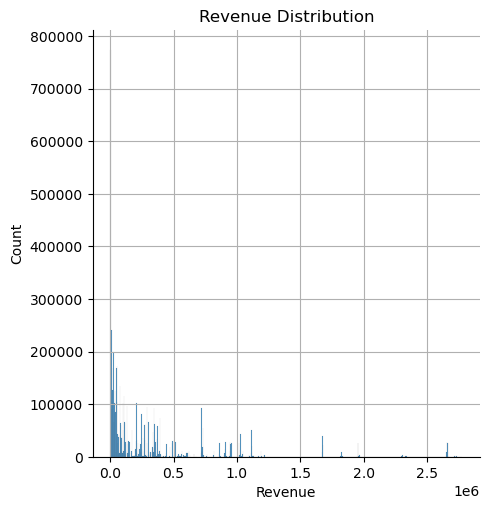

In [37]:
## distribution for the revenue column

plt.figure(figsize=(5,2), facecolor="#FA8072")
sns.displot(x="Revenue", data=df)
plt.grid(True)
plt.title("Revenue Distribution")
plt.show()

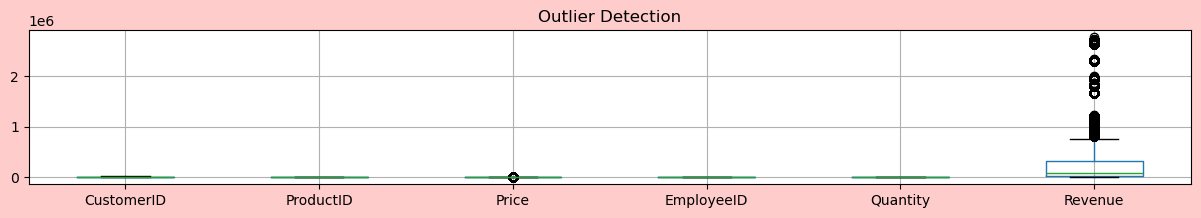

In [10]:
## checking for any outliers

plt.figure(figsize=(15,2), facecolor="#FFCCCC")
df.boxplot()
plt.grid(True)
plt.title("Outlier Detection")
plt.show()

In [11]:
# Dealing with outliers in the Total Sale Column using the Z-test

## getting the Z_score

sale_mean = df["Revenue"].mean()
std_dev = df["Revenue"].std()

df["Z_Score"] = (df["Revenue"] - sale_mean) / std_dev

# 3. Define threshold (Standard is 3)
threshold = 3

# 4. Identify the outliers
outliers = df[np.abs(df["Z_Score"]) > threshold]

# 5. Handle the outliers
#  Drop the outliers (Most common)
df_cleaned = df[np.abs(df["Z_Score"]) <= threshold].copy()

print(df_cleaned.drop(columns=["Z_Score"]))
df_cleaned

         CustomerID      Customer_Name            Employee_Name  ProductID  \
191753        19520     Wyatt Thompson  Reginald Blotchet-Halls        481   
191754        19520     Wyatt Thompson  Reginald Blotchet-Halls        481   
191755        19520     Wyatt Thompson  Reginald Blotchet-Halls        481   
191756        19520     Wyatt Thompson  Reginald Blotchet-Halls        481   
191757        19520     Wyatt Thompson  Reginald Blotchet-Halls        481   
...             ...                ...                      ...        ...   
6715216        3120  Cameron Rodriguez                 Ann Dull          4   
6715217        3120  Cameron Rodriguez                 Ann Dull          4   
6715218        3120  Cameron Rodriguez                 Ann Dull          4   
6715219        3120  Cameron Rodriguez                 Ann Dull          4   
6715220        3120  Cameron Rodriguez                 Ann Dull          4   

                       Product    Price  EmployeeID  Quantity  

,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Revenue,Z_Score
191753,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191754,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191755,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191756,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191757,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
...,...,...,...,...,...,...,...,...,...,...
6715216,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715217,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715218,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715219,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043


In [12]:
## dealing iwth outliers with the upper limit

# lower quantile 
q1 = df["Revenue"].quantile(0.25)

# upper quantile
q3 = df["Revenue"].quantile(0.75)

## interquartile range (iqr)
iqr = q3 - q1

# upper limit
upper_limit = q3 + ( 1.5 * iqr)

# lower limit
lower_limit = q1 - (1.5 * iqr)

## identifying the outliers
outliers = df[(df["Revenue"] <= upper_limit) | (df["Revenue"] >= lower_limit)]
outliers

,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Revenue,Z_Score
0,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,776,2776737.52,5.291946
1,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424
2,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424
3,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424
4,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424
...,...,...,...,...,...,...,...,...,...,...
6715216,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715217,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715218,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715219,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043


In [13]:
## dealing with the outliers

df1 = df[(df["Revenue"] > upper_limit) & (df["Revenue"] < lower_limit)]
df1

,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Revenue,Z_Score


In [14]:
df_cleaned

,CustomerID,Customer_Name,Employee_Name,ProductID,Product,Price,EmployeeID,Quantity,Revenue,Z_Score
191753,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191754,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191755,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191756,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
191757,19520,Wyatt Thompson,Reginald Blotchet-Halls,481,"Road-350-W Yellow, 48",1700.99,2,986,1677176.14,2.963131
...,...,...,...,...,...,...,...,...,...,...
6715216,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715217,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715218,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043
6715219,3120,Cameron Rodriguez,Ann Dull,4,Headset Ball Bearings,0.00,6,1014,0.00,-0.589043


In [15]:
## checking the no of outliers removed

print("Outliers:", len(df) - len(df_cleaned))

Outliers: 191753


###### -- N/B only the outlier detection method using the Z-test will be used in this case

In [16]:
data = df_cleaned

data.shape

(6523468, 10)

In [17]:
## renaming columns

data = df.rename(columns = {
    "CustomerID" : "Customer ID",
    "Customer_Name" : "Client",
    "Employee_Name" : "Employee",
    "ProductID": "Product ID"
} )

data.head(3)

,Customer ID,Client,Employee,Product ID,Product,Price,EmployeeID,Quantity,Revenue,Z_Score
0,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,776,2776737.52,5.291946
1,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424
2,2640,Brett Rana,Meander Smith,258,"Road-150 Red, 56",3578.27,19,763,2730220.01,5.193424


In [21]:
## dropping unwanted columns

data = data.drop(["Customer ID", "Product ID", "EmployeeID", "Z_Score"],axis=1)
data.head(3)

,Client,Employee,Product,Price,Quantity,Revenue
0,Brett Rana,Meander Smith,"Road-150 Red, 56",3578.27,776,2776737.52
1,Brett Rana,Meander Smith,"Road-150 Red, 56",3578.27,763,2730220.01
2,Brett Rana,Meander Smith,"Road-150 Red, 56",3578.27,763,2730220.01


### Exploratory Data Analysis

##### 1. KPIs

In [18]:
## total number of customers

print("Total Number of Customers:", len(data["Client"].unique()))

Total Number of Customers: 567


In [19]:
## total number of employees 

print("Total Number of Employees:", len(data["Employee"].unique()))

Total Number of Employees: 23


In [20]:
## total number of products 

print("Total Number of Product:", len(data["Product"].unique()))

Total Number of Product: 504


In [28]:
## average price

print("Average Price:", round(data["Price"].mean(),2))

Average Price: 525.36


In [21]:
## total quantity sold

print("Total Quantity Sold:", data["Quantity"].sum())

Total Quantity Sold: 3353696223


In [22]:
## Average Quantity Sold

print("Average Quantity Sold:", data["Quantity"].mean().astype(int))

Average Quantity Sold: 499


In [23]:
## Average Revenue

print("Average Revenue:", data["Revenue"].mean().astype(int))

Average Revenue: 278119


In [24]:
## Total Revenue

print("Total Revenue:", data["Revenue"].sum().astype(int))

Total Revenue: -2147483648


C:\Users\Alvin\AppData\Local\Temp\ipykernel_20984\1861661197.py:3: RuntimeWarning: invalid value encountered in cast
  print("Total Revenue:", data["Revenue"].sum().astype(int))


In [40]:
## most common product sold

print("Most Common Product Sold:", data["Product"].mode()[0])

Most Common Product Sold: ML Road Rim


In [25]:
## Employee with the most sales

print("Employee With The Most Sales:", data["Employee"].mode()[0])

Employee With The Most Sales: Abraham Bennet


In [26]:
## Client with the highest sales

print("Client With The Most Sales:", data["Client"].mode()[0])

Client With The Most Sales: Richard White


##### 2. Univariate Analysis 

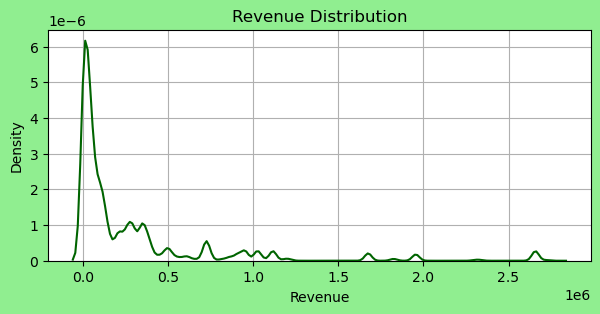

In [27]:
## revenue distribution

plt.figure(figsize=(7,3), facecolor = "lightgreen")
sns.kdeplot(x="Revenue", data=data, color="darkgreen")
plt.grid(True)
plt.title("Revenue Distribution", loc="center")
plt.show()

##### Interpretation:

The revenue is skewed to the right, which means that the mean is greater than the median. 

##### Implication:

This implies that vast majority of transactions & customers generate smaller, lower-to-moderate revenue amounts.

#### 2. Bivariate Analysis

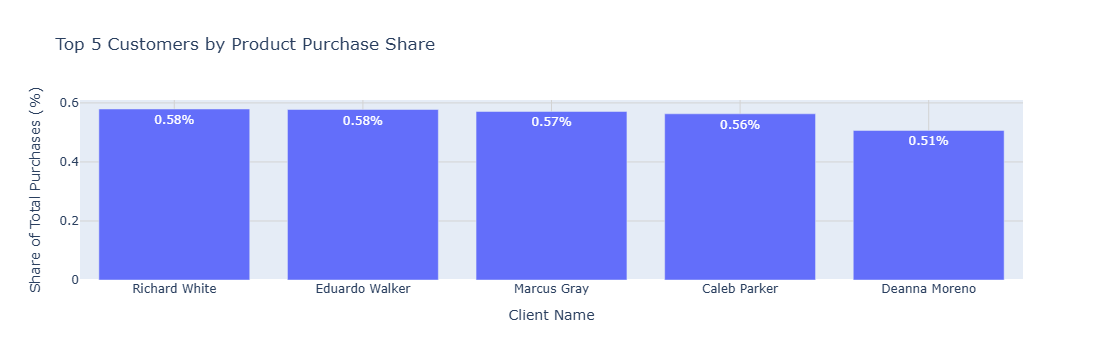

In [38]:
## the top 5 clients

# 1. Create pivot table with purchase counts
pivot = data.pivot_table(index="Client", values="Product", aggfunc="count")

# 2. Calculate percentage share relative to ALL client purchases
pivot["Percentage"] = (pivot["Product"] / pivot["Product"].sum()) * 100

# 3. Extract top 5 customers and reset index
top5_customers = pivot.sort_values(by="Product", ascending=False).head(5)
table = top5_customers.reset_index()

# 4. Plot vertical bar chart
fig = px.bar(
    table,
    x="Client",
    y="Percentage",
    orientation="v",
    title="Top 5 Customers by Product Purchase Share",
    text="Percentage",
)

# Format bar labels and hover tooltip
fig.update_traces(
    texttemplate="%{y:.2f}%",
    textposition="inside",
    hovertemplate="<b>%{x}</b><br>Share: %{y:.2f}%<extra></extra>",
)

# Customize layout axes and appearance
fig.update_layout(
    xaxis=dict(title="Client Name", showgrid=True, gridcolor="lightgray"),
    yaxis=dict(title="Share of Total Purchases (%)", showgrid=True, gridcolor="lightgray"),
    uniformtext_minsize=10,
    uniformtext_mode="hide",
)

fig.show()

#### Interpretation:

- Richard White and Eduardo Walter have the highest percentage of products purchased as compared to the rest of the clients.

#### Recommendation:
- Incentivise the above clients with discount coupons, 